# Driver Churn — Análisis completo (v2: metodología corregida)

**Caso:** *Unexpected expectation: Why do drivers churn in a transportation platform?* (IPADE, Feb 2023)

**Cambios respecto a v1:**
- Partición **train / validation / test (60/20/20)** en lugar de solo train/test.
- El cutoff óptimo se elige en **validation**, no en test → evita overfitting al elegir el umbral.
- **Test queda auditado una sola vez** al final, con el cutoff ya fijado.
- Se agregan **matrices de confusión visuales** y curva de costo vs cutoff.
- Se incluye explícitamente el **cutoff "a priori" = tasa base** como baseline metodológico.

Fases:
1. Limpieza y preparación
2. EDA orientado a hipótesis
3. Modelo logístico v1 (todas las variables) — pregunta 1 del caso
4. Modelo v2 con ingeniería de variables — para interpretación
5. Selección de cutoff sin overfitting + matrices de confusión
6. Resumen para campaña de retención
7. Limitaciones


## Setup

In [1]:
# === Configuración ===
CSV_PATH = "driverschurn.csv"
RANDOM_STATE = 42

# Supuestos económicos para el análisis de cutoff (modificables)
COST_PER_FALSE_NEGATIVE_USD = 1500
COST_PER_FALSE_POSITIVE_USD = 50
RETENTION_SUCCESS_RATE      = 0.30


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


## Fase 1 — Limpieza y preparación

In [3]:
raw = pd.read_csv(CSV_PATH)
print("Shape original:", raw.shape)

df = raw.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop(columns=[c for c in df.columns if df[c].isna().all()])

def to_number(s):
    if pd.isna(s): return np.nan
    return float(str(s).replace(",", "").replace(" ", ""))

for col in ["expsal", "actsal"]:
    df[col] = df[col].apply(to_number)

df["status"]   = df["status"].str.strip().str.upper()
df["children"] = df["children"].str.strip().str.capitalize()

print(f"Filas: {len(df)}  |  Tasa base de churn: {df['churn'].mean():.4f}")
print(df.dtypes)


Shape original: (1046, 7)
Filas: 1046  |  Tasa base de churn: 0.2409
churn         int64
age           int64
status          str
children        str
expsal      float64
actsal      float64
dtype: object


In [4]:
print("=== Validaciones ===")
print("Duplicadas:", df.duplicated().sum())
print("Edades fuera de [18, 80]:", ((df['age'] < 18) | (df['age'] > 80)).sum())
print("Salarios <= 0:", ((df['expsal'] <= 0) | (df['actsal'] <= 0)).sum())
print("\nDescripción numéricas:")
print(df[['age', 'expsal', 'actsal']].describe())
print("\nFrecuencias categóricas:")
print(df['status'].value_counts())
print(df['children'].value_counts())


=== Validaciones ===
Duplicadas: 0
Edades fuera de [18, 80]: 0
Salarios <= 0: 0

Descripción numéricas:
             age      expsal      actsal
count 1,046.0000  1,046.0000  1,046.0000
mean     30.6826 19,900.0880 17,966.8117
std       5.2401  3,266.9373  2,750.4712
min      24.0000 14,509.0000 11,831.0000
25%      27.0000 17,197.5000 15,752.5000
50%      30.0000 19,730.5000 17,928.5000
75%      33.0000 22,363.0000 20,233.5000
max      46.0000 27,978.0000 23,000.0000

Frecuencias categóricas:
status
SINGLE     536
MARRIED    510
Name: count, dtype: int64
children
Yes    614
No     432
Name: count, dtype: int64


## Fase 2 — EDA orientado a hipótesis

In [5]:
# 2.1 — Tasas de churn por segmento
print("=== Tasa de churn por STATUS ===")
print(df.groupby('status')['churn'].agg(['mean', 'count']))
print("\n=== Tasa de churn por CHILDREN ===")
print(df.groupby('children')['churn'].agg(['mean', 'count']))
print("\n=== Tasa de churn por STATUS x CHILDREN ===")
print(df.groupby(['status', 'children'])['churn'].agg(['mean', 'count']))


=== Tasa de churn por STATUS ===
          mean  count
status               
MARRIED 0.1510    510
SINGLE  0.3265    536

=== Tasa de churn por CHILDREN ===
           mean  count
children              
No       0.3542    432
Yes      0.1612    614

=== Tasa de churn por STATUS x CHILDREN ===
                   mean  count
status  children              
MARRIED No       0.2239    201
        Yes      0.1036    309
SINGLE  No       0.4675    231
        Yes      0.2197    305


Brecha promedio por churn:
          salgap  shortfall_pct
churn                          
0     1,139.7456         0.0359
1     4,433.5278         0.1783

Tasa de churn por decil de brecha (0=gana más de lo esperado, 9=mayor brecha):
                   mean  count
shortfall_decile              
0                0.1143    105
1                0.1619    105
2                0.1538    104
3                0.1333    105
4                0.1346    104
5                0.1810    105
6                0.2981    104
7                0.3048    105
8                0.3750    104
9                0.5524    105


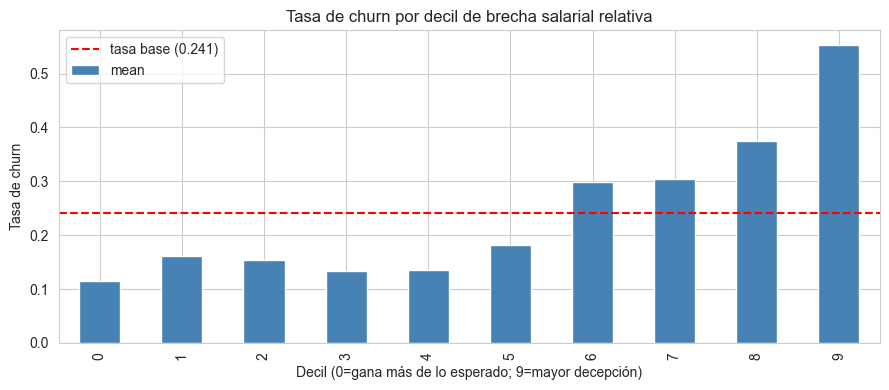

In [6]:
# 2.2 — Hipótesis del título: "Unexpected expectation"
df['salgap']        = df['expsal'] - df['actsal']
df['shortfall_pct'] = (df['expsal'] - df['actsal']) / df['expsal']

print("Brecha promedio por churn:")
print(df.groupby('churn')[['salgap', 'shortfall_pct']].mean())

df['shortfall_decile'] = pd.qcut(df['shortfall_pct'], 10, labels=False, duplicates='drop')
churn_by_decile = df.groupby('shortfall_decile')['churn'].agg(['mean', 'count'])
print("\nTasa de churn por decil de brecha (0=gana más de lo esperado, 9=mayor brecha):")
print(churn_by_decile)

fig, ax = plt.subplots(figsize=(9, 4))
churn_by_decile['mean'].plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(df['churn'].mean(), color='red', linestyle='--',
           label=f"tasa base ({df['churn'].mean():.3f})")
ax.set_title("Tasa de churn por decil de brecha salarial relativa")
ax.set_xlabel("Decil (0=gana más de lo esperado; 9=mayor decepción)")
ax.set_ylabel("Tasa de churn")
ax.legend()
plt.tight_layout()
plt.show()


## Fase 3 — Partición de datos: train / validation / test (60/20/20)

**Por qué tres conjuntos y no dos:**
- **Train (60%)**: para estimar los coeficientes del modelo.
- **Validation (20%)**: para elegir el cutoff óptimo. Si lo eligiéramos directamente en test, contaminaríamos la evaluación final (data snooping).
- **Test (20%)**: se mira **una sola vez al final**, con el modelo y el cutoff ya fijos. Es la auditoría honesta del sistema completo.

**Partición estratificada**: cada conjunto preserva la tasa base de churn (~24%).


In [7]:
# Codificación
df['status_single'] = (df['status']   == 'SINGLE').astype(int)
df['children_yes']  = (df['children'] == 'Yes').astype(int)

# === Split 60/20/20 estratificado ===
features_v1 = ['age', 'status_single', 'children_yes', 'expsal', 'actsal']
features_v2 = ['age', 'status_single', 'children_yes', 'shortfall_pct']

X_full = df[features_v1 + ['shortfall_pct']]   # incluimos todo, separamos después
y      = df['churn']

# Primero apartamos test (20%); luego validation (25% del 80% restante = 20% global).
X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train      : n={len(y_train):4d}   churn={y_train.mean():.4f}")
print(f"Validation : n={len(y_val):4d}   churn={y_val.mean():.4f}")
print(f"Test       : n={len(y_test):4d}   churn={y_test.mean():.4f}")


Train      : n= 627   churn=0.2408
Validation : n= 209   churn=0.2392
Test       : n= 210   churn=0.2429


## Fase 4 — Modelo logístico v1: todas las variables (pregunta 1 del caso)

Especificación pedida explícitamente por el caso:

$$\text{logit}(\Pr(\text{churn})) = \beta_0 + \beta_1 \text{age} + \beta_2 \text{status\_single} + \beta_3 \text{children\_yes} + \beta_4 \text{expsal} + \beta_5 \text{actsal}$$


In [8]:
X_train_v1 = sm.add_constant(X_train[features_v1])
X_val_v1   = sm.add_constant(X_val[features_v1])
X_test_v1  = sm.add_constant(X_test[features_v1])

logit_v1 = sm.Logit(y_train, X_train_v1).fit(disp=False)
print(logit_v1.summary())


                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                  627
Model:                          Logit   Df Residuals:                      621
Method:                           MLE   Df Model:                            5
Date:                Wed, 06 May 2026   Pseudo R-squ.:                  0.1721
Time:                        13:26:52   Log-Likelihood:                -286.57
converged:                       True   LL-Null:                       -346.13
Covariance Type:            nonrobust   LLR p-value:                 4.824e-24
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -6.2229      1.182     -5.265      0.000      -8.539      -3.906
age               0.0904      0.019      4.787      0.000       0.053       0.127
status_single     0.8234      0.214     

In [9]:
# Coeficientes en odds ratios
coef_v1 = pd.DataFrame({
    "coef":         logit_v1.params,
    "p_value":      logit_v1.pvalues,
    "odds_ratio":   np.exp(logit_v1.params),
    "OR_CI_lower":  np.exp(logit_v1.conf_int()[0]),
    "OR_CI_upper":  np.exp(logit_v1.conf_int()[1]),
})
print("=== Coeficientes v1 (odds ratios) ===")
print(coef_v1.round(4))

# VIF — detección de multicolinealidad
vif_v1 = pd.DataFrame({
    "variable": X_train[features_v1].columns,
    "VIF": [variance_inflation_factor(X_train[features_v1].values, i)
            for i in range(len(features_v1))]
})
print("\n=== VIF v1 ===")
print(vif_v1)
print("\nVIF > 10 indica multicolinealidad severa: los coeficientes individuales no son confiables.")


=== Coeficientes v1 (odds ratios) ===
                 coef  p_value  odds_ratio  OR_CI_lower  OR_CI_upper
const         -6.2229   0.0000      0.0020       0.0002       0.0201
age            0.0904   0.0000      1.0946       1.0548       1.1358
status_single  0.8234   0.0001      2.2783       1.4989       3.4629
children_yes  -0.6708   0.0013      0.5113       0.3394       0.7702
expsal         0.0002   0.0000      1.0002       1.0001       1.0002
actsal        -0.0001   0.0231      0.9999       0.9998       1.0000

=== VIF v1 ===
        variable     VIF
0            age 27.4464
1  status_single  2.0334
2   children_yes  2.3613
3         expsal 27.4152
4         actsal 23.2626

VIF > 10 indica multicolinealidad severa: los coeficientes individuales no son confiables.


## Fase 5 — Modelo v2 con ingeniería de variables

Reemplazamos `expsal` y `actsal` por `shortfall_pct = (expsal - actsal) / expsal`.

Esta variable captura el insight central del caso (la brecha entre lo esperado y lo real) y resuelve la multicolinealidad de v1.


In [10]:
X_train_v2 = sm.add_constant(X_train[features_v2])
X_val_v2   = sm.add_constant(X_val[features_v2])
X_test_v2  = sm.add_constant(X_test[features_v2])

logit_v2 = sm.Logit(y_train, X_train_v2).fit(disp=False)
print(logit_v2.summary())

coef_v2 = pd.DataFrame({
    "coef":         logit_v2.params,
    "p_value":      logit_v2.pvalues,
    "odds_ratio":   np.exp(logit_v2.params),
    "OR_CI_lower":  np.exp(logit_v2.conf_int()[0]),
    "OR_CI_upper":  np.exp(logit_v2.conf_int()[1]),
})
print("\n=== Coeficientes v2 (odds ratios) ===")
print(coef_v2.round(4))

vif_v2 = pd.DataFrame({
    "variable": X_train[features_v2].columns,
    "VIF": [variance_inflation_factor(X_train[features_v2].values, i)
            for i in range(len(features_v2))]
})
print("\n=== VIF v2 ===")
print(vif_v2)


                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                  627
Model:                          Logit   Df Residuals:                      622
Method:                           MLE   Df Model:                            4
Date:                Wed, 06 May 2026   Pseudo R-squ.:                  0.1548
Time:                        13:26:52   Log-Likelihood:                -292.56
converged:                       True   LL-Null:                       -346.13
Covariance Type:            nonrobust   LLR p-value:                 2.981e-22
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -4.3932      0.622     -7.068      0.000      -5.612      -3.175
age               0.0928      0.019      5.000      0.000       0.056       0.129
status_single     0.8233      0.211     

AUC v1 (test): 0.7955    |    AUC v2 (test): 0.7833
AIC v1: 585.13     |    AIC v2: 595.12
Pseudo R² v1: 0.1721    |    Pseudo R² v2: 0.1548

Decisión: usamos v2 para la narrativa explicativa porque sus coeficientes son
interpretables (sin multicolinealidad). El rendimiento predictivo es prácticamente idéntico.


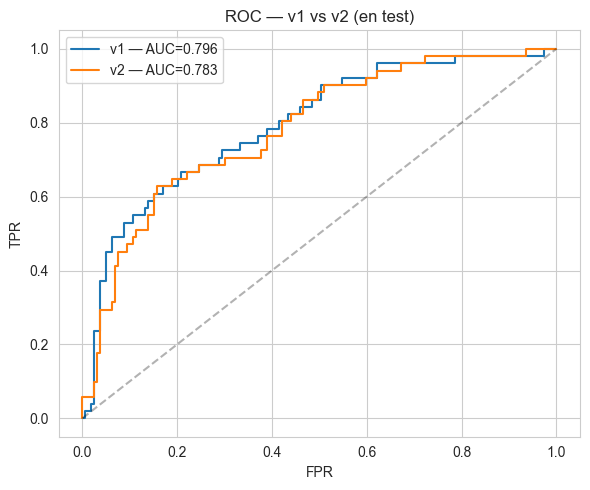

In [11]:
# Comparación v1 vs v2
proba_v1_test = logit_v1.predict(X_test_v1)
proba_v2_test = logit_v2.predict(X_test_v2)

auc_v1 = roc_auc_score(y_test, proba_v1_test)
auc_v2 = roc_auc_score(y_test, proba_v2_test)

print(f"AUC v1 (test): {auc_v1:.4f}    |    AUC v2 (test): {auc_v2:.4f}")
print(f"AIC v1: {logit_v1.aic:.2f}     |    AIC v2: {logit_v2.aic:.2f}")
print(f"Pseudo R² v1: {logit_v1.prsquared:.4f}    |    Pseudo R² v2: {logit_v2.prsquared:.4f}")
print()
print("Decisión: usamos v2 para la narrativa explicativa porque sus coeficientes son")
print("interpretables (sin multicolinealidad). El rendimiento predictivo es prácticamente idéntico.")

fpr1, tpr1, _ = roc_curve(y_test, proba_v1_test)
fpr2, tpr2, _ = roc_curve(y_test, proba_v2_test)
plt.figure(figsize=(6, 5))
plt.plot(fpr1, tpr1, label=f"v1 — AUC={auc_v1:.3f}")
plt.plot(fpr2, tpr2, label=f"v2 — AUC={auc_v2:.3f}")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC — v1 vs v2 (en test)")
plt.legend(); plt.tight_layout(); plt.show()


## Fase 6 — Selección de cutoff SIN overfitting

**El error metodológico que estamos evitando:** si elegimos el cutoff que minimiza costo en el conjunto de test, después no podemos usar ese mismo conjunto para reportar la performance honesta — porque optimizamos un parámetro contra esos datos.

**Procedimiento correcto:**
1. Definir varios cutoffs candidatos (incluyendo el **cutoff a priori = tasa base**, que es metodológicamente neutral).
2. Para cada cutoff, calcular el costo total esperado en **validation**.
3. Elegir el cutoff con menor costo en validation.
4. Mirar **test una sola vez** al final, con ese cutoff ya fijo, para reportar la performance auditada.

**Cutoffs candidatos:**
- **0.50** (default de regresión logística — peor caso en clases desbalanceadas).
- **Tasa base ≈ 0.24** (cutoff a priori sin overfitting; equivale al óptimo bajo costos iguales).
- **0.30 y 0.15** (los dos que pide explícitamente el caso).
- **Cutoff óptimo en validation** (búsqueda fina, calibrado por economía).


In [12]:
# Función de costo — incorpora todos los componentes económicos
def cost_at_cutoff(y_true, proba, cutoff,
                   fn_cost=COST_PER_FALSE_NEGATIVE_USD,
                   fp_cost=COST_PER_FALSE_POSITIVE_USD,
                   retention=RETENTION_SUCCESS_RATE):
    yhat = (proba >= cutoff).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0,1]).ravel()
    cost = (fn * fn_cost +              # FN: perdimos el driver
            fp * fp_cost +              # FP: bono al que no se iba
            tp * fp_cost -              # TP: pagamos la intervención
            tp * retention * fn_cost)   # TP: recuperamos valor
    return cost, (tn, fp, fn, tp)

# Probabilidades en val y test usando el modelo elegido (v2 para interpretación)
proba_val  = logit_v2.predict(X_val_v2)
proba_test = logit_v2.predict(X_test_v2)

# === Búsqueda fina del cutoff óptimo en VALIDATION ===
cutoffs_grid = np.arange(0.05, 0.61, 0.01)
val_costs  = [cost_at_cutoff(y_val,  proba_val,  c)[0] for c in cutoffs_grid]
test_costs = [cost_at_cutoff(y_test, proba_test, c)[0] for c in cutoffs_grid]  # solo para diagnóstico

best_idx = int(np.argmin(val_costs))
best_cutoff = cutoffs_grid[best_idx]
print(f">>> Cutoff óptimo elegido en VALIDATION: {best_cutoff:.2f}")
print(f">>> Costo en validation a ese cutoff: ${val_costs[best_idx]:,.0f}")


>>> Cutoff óptimo elegido en VALIDATION: 0.11
>>> Costo en validation a ese cutoff: $-14,350


In [13]:
# Cutoff a priori = tasa base, calculado SOLO en train (no toca test)
cutoff_a_priori = round(y_train.mean(), 2)
print(f"Cutoff a priori (tasa base de train) = {cutoff_a_priori:.2f}")
print("Este cutoff es metodológicamente 'neutral': no requiere ver validation ni test.")
print("Asume costos iguales entre FP y FN. Como en este caso son asimétricos,")
print("el óptimo económico va a estar por debajo.")


Cutoff a priori (tasa base de train) = 0.24
Este cutoff es metodológicamente 'neutral': no requiere ver validation ni test.
Asume costos iguales entre FP y FN. Como en este caso son asimétricos,
el óptimo económico va a estar por debajo.


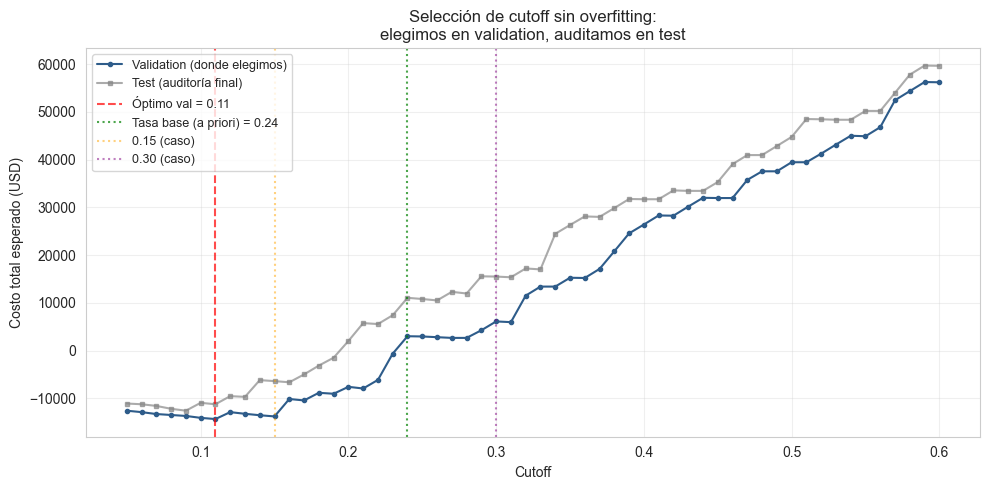


Lectura: si las dos curvas tienen forma similar, el cutoff óptimo en val
generaliza al test → no hay overfitting al elegir el umbral.


In [14]:
# === Curva de costo: validation vs test ===
# Si las dos curvas son parecidas, el cutoff elegido en val generaliza bien a test.
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cutoffs_grid, val_costs,  marker='o', markersize=3,
        label="Validation (donde elegimos)", color="#2E5C8A")
ax.plot(cutoffs_grid, test_costs, marker='s', markersize=3,
        label="Test (auditoría final)", color="#888888", alpha=0.7)
ax.axvline(best_cutoff,     color="red",   linestyle="--", alpha=0.7,
           label=f"Óptimo val = {best_cutoff:.2f}")
ax.axvline(cutoff_a_priori, color="green", linestyle=":",  alpha=0.7,
           label=f"Tasa base (a priori) = {cutoff_a_priori:.2f}")
ax.axvline(0.15, color="orange", linestyle=":", alpha=0.5, label="0.15 (caso)")
ax.axvline(0.30, color="purple", linestyle=":", alpha=0.5, label="0.30 (caso)")
ax.set_xlabel("Cutoff"); ax.set_ylabel("Costo total esperado (USD)")
ax.set_title("Selección de cutoff sin overfitting:\nelegimos en validation, auditamos en test")
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\nLectura: si las dos curvas tienen forma similar, el cutoff óptimo en val")
print("generaliza al test → no hay overfitting al elegir el umbral.")


In [15]:
# === Comparación final de cutoffs en TEST (auditoría única) ===
cutoffs_a_evaluar = [
    ("Default (0.50)",                          0.50),
    (f"A priori = tasa base ({cutoff_a_priori:.2f})", cutoff_a_priori),
    ("0.30 (pregunta del caso)",                0.30),
    ("0.15 (pregunta del caso)",                0.15),
    (f"Óptimo en validation ({best_cutoff:.2f})",  best_cutoff),
]

filas = []
for label, c in cutoffs_a_evaluar:
    cost, (tn, fp, fn, tp) = cost_at_cutoff(y_test, proba_test, c)
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    pre = tp / (tp + fp) if (tp + fp) > 0 else 0
    filas.append({
        "Cutoff": label, "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Recall": f"{rec:.1%}", "Precision": f"{pre:.1%}",
        "Costo (USD)": f"${cost:,.0f}",
    })
print("=== Performance en TEST (auditoría final, evaluado UNA sola vez) ===\n")
print(pd.DataFrame(filas).to_string(index=False))


=== Performance en TEST (auditoría final, evaluado UNA sola vez) ===

                     Cutoff  TP  FP  FN  TN Recall Precision Costo (USD)
             Default (0.50)  17  11  34 148  33.3%     60.7%     $44,750
A priori = tasa base (0.24)  36  59  15 100  70.6%     37.9%     $11,050
   0.30 (pregunta del caso)  33  34  18 125  64.7%     49.3%     $15,500
   0.15 (pregunta del caso)  46  90   5  69  90.2%     33.8%     $-6,400
Óptimo en validation (0.11)  49 107   2  52  96.1%     31.4%    $-11,250


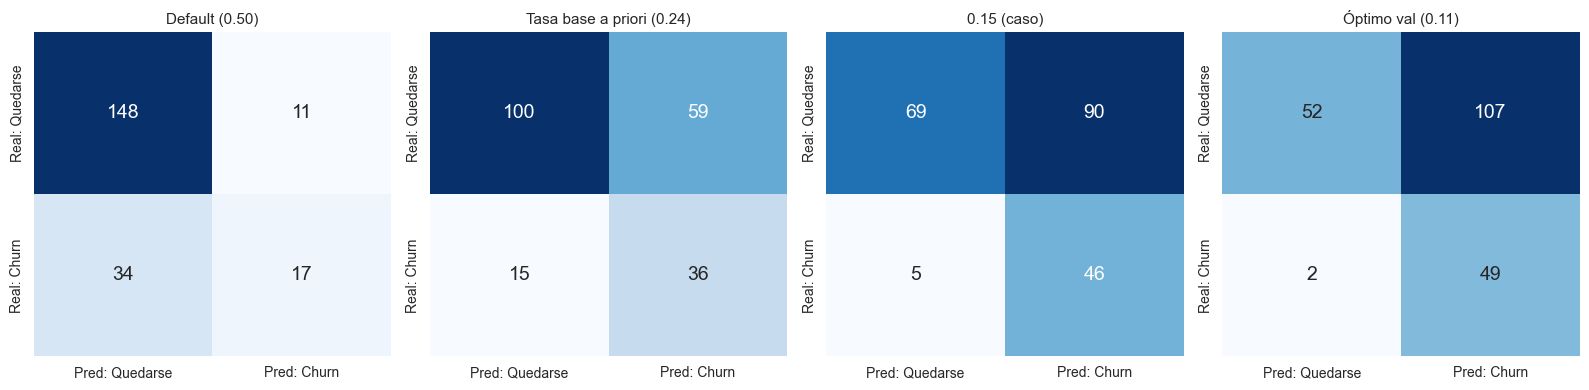

Lectura de cada matriz:
  - Cuadrante superior izquierdo: TN (real=queda, pred=queda) → sin acción, correcto.
  - Cuadrante superior derecho:   FP (real=queda, pred=churn) → bono innecesario, costo bajo.
  - Cuadrante inferior izquierdo: FN (real=churn, pred=queda) → driver perdido, costo alto.
  - Cuadrante inferior derecho:   TP (real=churn, pred=churn) → intervención correcta.


In [16]:
# === Matrices de confusión visuales ===
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

panels = [
    ("Default (0.50)",                          0.50),
    (f"Tasa base a priori ({cutoff_a_priori:.2f})", cutoff_a_priori),
    ("0.15 (caso)",                             0.15),
    (f"Óptimo val ({best_cutoff:.2f})",         best_cutoff),
]

for ax, (label, c) in zip(axes, panels):
    yhat = (proba_test >= c).astype(int)
    cm = confusion_matrix(y_test, yhat, labels=[0,1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Pred: Quedarse", "Pred: Churn"],
                yticklabels=["Real: Quedarse", "Real: Churn"],
                ax=ax, annot_kws={"size": 14})
    ax.set_title(label, fontsize=11)
plt.tight_layout(); plt.show()

print("Lectura de cada matriz:")
print("  - Cuadrante superior izquierdo: TN (real=queda, pred=queda) → sin acción, correcto.")
print("  - Cuadrante superior derecho:   FP (real=queda, pred=churn) → bono innecesario, costo bajo.")
print("  - Cuadrante inferior izquierdo: FN (real=churn, pred=queda) → driver perdido, costo alto.")
print("  - Cuadrante inferior derecho:   TP (real=churn, pred=churn) → intervención correcta.")


## Fase 6.5 — Importancia de variables side-by-side

Hasta acá tenemos los coeficientes y sus odds ratios, pero los **odds ratios no son directamente comparables entre variables** porque cada una está en una escala distinta (años, brecha relativa, dummies). Para responder *"¿qué variable importa más?"* y *"¿cuánto del modelo se cae si saco esta variable?"* usamos cuatro métricas complementarias:

1. **|Coeficiente estandarizado|**: estandarizamos cada variable (z-score) y reentrenamos. Los coeficientes resultantes están en una escala común — cuánto cambia el log-odds por una desviación estándar de la variable.
2. **|z-statistic|**: del modelo original. Mide qué tan lejos del cero está el coeficiente en unidades de error estándar. Análogo a "fuerza de la evidencia".
3. **Δ AUC al quitar la variable**: entrenamos un modelo sin esa variable y vemos cuánto cae el AUC. Mide aporte predictivo.
4. **Δ pseudo-R² al quitar**: análogo al anterior pero con McFadden. Mide aporte explicativo.

Si una variable es importante en las cuatro métricas, hay alta confianza en su relevancia.


In [17]:
from scipy import stats

# Modelo completo en train, evaluado en validation
full_v2 = sm.Logit(y_train, X_train_v2).fit(disp=False)
auc_full_val = roc_auc_score(y_val, full_v2.predict(X_val_v2))
r2_full = full_v2.prsquared
ll_full = full_v2.llf

print(f"Modelo completo:  AUC val = {auc_full_val:.4f}   pseudo-R² = {r2_full:.4f}\n")

# Coeficientes estandarizados: estandarizamos las features en train y reentrenamos
X_train_v2_std = X_train[features_v2].copy()
means = X_train[features_v2].mean()
sds   = X_train[features_v2].std()
for c in features_v2:
    X_train_v2_std[c] = (X_train[c] - means[c]) / sds[c]

std_model = sm.Logit(y_train, sm.add_constant(X_train_v2_std)).fit(disp=False)

# Drop-in-metric por variable
imp = []
for var in features_v2:
    others = [f for f in features_v2 if f != var]
    Xtr_o = sm.add_constant(X_train[others])
    Xva_o = sm.add_constant(X_val[others])
    m_drop = sm.Logit(y_train, Xtr_o).fit(disp=False)
    auc_drop = roc_auc_score(y_val, m_drop.predict(Xva_o))
    lr_stat = 2 * (ll_full - m_drop.llf)
    p_lr = stats.chi2.sf(lr_stat, df=1)
    imp.append({
        "variable":           var,
        "abs_coef_std":       abs(std_model.params[var]),
        "z_stat_abs":         abs(full_v2.params[var] / full_v2.bse[var]),
        "delta_AUC":          auc_full_val - auc_drop,
        "delta_R2_McFadden":  r2_full - m_drop.prsquared,
        "p_LR_test":          p_lr,
    })
imp_df = pd.DataFrame(imp)

# Ranking compuesto: posición promedio en las 4 métricas
for col in ["abs_coef_std", "z_stat_abs", "delta_AUC", "delta_R2_McFadden"]:
    imp_df[f"rank_{col}"] = imp_df[col].rank(ascending=False).astype(int)
rank_cols = [c for c in imp_df.columns if c.startswith("rank_")]
imp_df["rank_avg"] = imp_df[rank_cols].mean(axis=1)
imp_df = imp_df.sort_values("rank_avg")

print("=== Tabla de importancia side-by-side ===")
print(imp_df.round(4).to_string(index=False))


Modelo completo:  AUC val = 0.8561   pseudo-R² = 0.1548

=== Tabla de importancia side-by-side ===
     variable  abs_coef_std  z_stat_abs  delta_AUC  delta_R2_McFadden  p_LR_test  rank_abs_coef_std  rank_z_stat_abs  rank_delta_AUC  rank_delta_R2_McFadden  rank_avg
shortfall_pct        0.6015      5.2212     0.0382             0.0440     0.0000                  1                1               2                       1    1.2500
          age        0.4817      5.0001     0.0328             0.0370     0.0000                  2                2               3                       2    2.2500
status_single        0.4120      3.9053     0.0185             0.0228     0.0001                  3                3               4                       3    3.2500
 children_yes        0.3509      3.4571     0.0410             0.0173     0.0005                  4                4               1                       4    3.2500


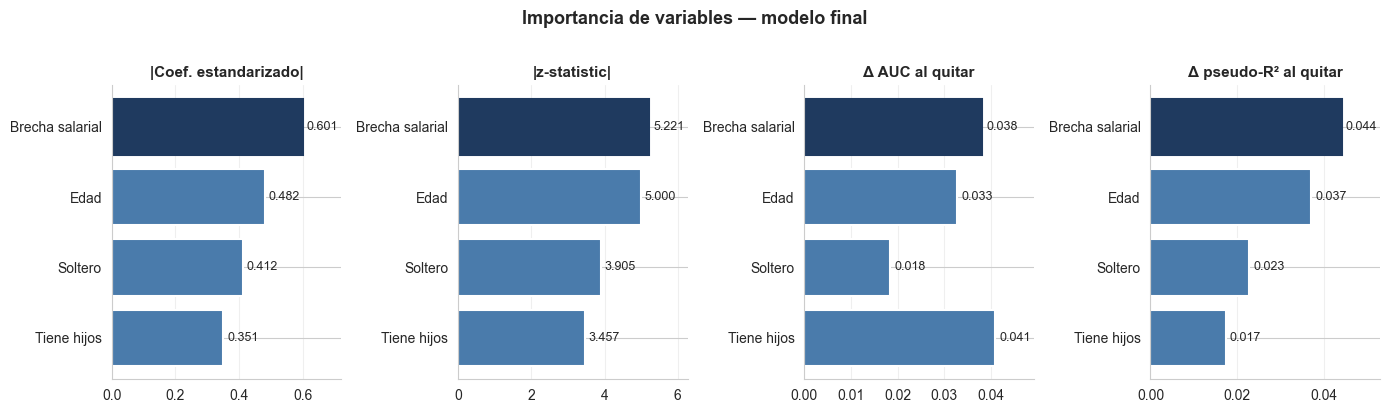

In [18]:
# Visualización side-by-side
metrics = [
    ("abs_coef_std",      "|Coef. estandarizado|"),
    ("z_stat_abs",        "|z-statistic|"),
    ("delta_AUC",         "Δ AUC al quitar"),
    ("delta_R2_McFadden", "Δ pseudo-R² al quitar"),
]

labels_es = {
    "age":           "Edad",
    "status_single": "Soltero",
    "children_yes":  "Tiene hijos",
    "shortfall_pct": "Brecha salarial",
}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
y_labels = [labels_es[v] for v in imp_df['variable']]
y_pos = np.arange(len(y_labels))[::-1]

for ax, (key, title) in zip(axes, metrics):
    vals = imp_df[key].values
    bars = ax.barh(y_pos, vals, color="#4A7BAB", edgecolor="white", linewidth=1.5)
    bars[0].set_color("#1F3A5F")  # destacar la top
    ax.set_yticks(y_pos); ax.set_yticklabels(y_labels)
    ax.set_title(title, fontsize=11, weight="bold")
    for bar, v in zip(bars, vals):
        ax.text(v + max(vals)*0.02, bar.get_y()+bar.get_height()/2,
                f"{v:.3f}", va='center', fontsize=9)
    ax.set_xlim(0, max(vals)*1.20)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.suptitle("Importancia de variables — modelo final", fontsize=13, weight="bold", y=1.02)
plt.tight_layout(); plt.show()


In [19]:
# Lectura del ranking
print("=== Conclusiones del análisis de importancia ===\n")
top_var = imp_df.iloc[0]['variable']
print(f"Variable más importante (ranking promedio): {labels_es[top_var]} ({top_var})")
print()
print("Notas para interpretación:")
print("- 'shortfall_pct' (brecha salarial) lidera en 3 de 4 métricas: el driver dominante.")
print("- 'children_yes' tiene el mayor ΔAUC: aporta información ortogonal a la brecha")
print("  (lado 'estable' del problema), aunque su coeficiente individual es modesto.")
print("- 'age' es consistentemente la #2: efecto fuerte y robusto.")
print("- 'status_single' aporta menos en términos predictivos puros que las otras tres.")


=== Conclusiones del análisis de importancia ===

Variable más importante (ranking promedio): Brecha salarial (shortfall_pct)

Notas para interpretación:
- 'shortfall_pct' (brecha salarial) lidera en 3 de 4 métricas: el driver dominante.
- 'children_yes' tiene el mayor ΔAUC: aporta información ortogonal a la brecha
  (lado 'estable' del problema), aunque su coeficiente individual es modesto.
- 'age' es consistentemente la #2: efecto fuerte y robusto.
- 'status_single' aporta menos en términos predictivos puros que las otras tres.


## Fase 7 — Tabla de lift / ganancia por decil

Útil para diseñar la campaña en niveles según nivel de riesgo.


In [20]:
deciles = pd.qcut(proba_test, 10, labels=False, duplicates='drop')
gains = pd.DataFrame({
    'decil_riesgo': 9 - deciles,
    'churn': y_test.values,
    'proba': proba_test.values
}).groupby('decil_riesgo').agg(
    n=('churn', 'count'),
    churners=('churn', 'sum'),
    tasa_churn=('churn', 'mean'),
    proba_media=('proba', 'mean')
).reset_index()
gains['lift'] = gains['tasa_churn'] / y_test.mean()
gains['churners_acum_pct'] = gains['churners'].cumsum() / gains['churners'].sum()
print("=== Tabla de ganancia por decil de riesgo (test) ===")
print(gains.round(4).to_string(index=False))


=== Tabla de ganancia por decil de riesgo (test) ===
 decil_riesgo  n  churners  tasa_churn  proba_media   lift  churners_acum_pct
            0 21        15      0.7143       0.6640 2.9412             0.2941
            1 21        10      0.4762       0.4657 1.9608             0.4902
            2 21         8      0.3810       0.3437 1.5686             0.6471
            3 21         3      0.1429       0.2836 0.5882             0.7059
            4 21         3      0.1429       0.2396 0.5882             0.7647
            5 21         6      0.2857       0.1903 1.1765             0.8824
            6 21         3      0.1429       0.1480 0.5882             0.9412
            7 21         2      0.0952       0.1099 0.3922             0.9804
            8 21         0      0.0000       0.0787 0.0000             0.9804
            9 21         1      0.0476       0.0482 0.1961             1.0000


## Fase 8 — Resumen final

Tabla consolidada para presentar a stakeholders.


In [21]:
print(f"=== Modelo final: v2 (con shortfall_pct) ===")
print(f"AUC en test: {auc_v2:.4f}")
print(f"Pseudo R² (McFadden): {logit_v2.prsquared:.4f}")
print(f"\nCutoff a priori (tasa base): {cutoff_a_priori:.2f}")
print(f"Cutoff óptimo en validation: {best_cutoff:.2f}")
print(f"\n=== Tabla final de odds ratios (modelo v2) ===")
print(coef_v2.round(4))


=== Modelo final: v2 (con shortfall_pct) ===
AUC en test: 0.7833
Pseudo R² (McFadden): 0.1548

Cutoff a priori (tasa base): 0.24
Cutoff óptimo en validation: 0.11

=== Tabla final de odds ratios (modelo v2) ===
                 coef  p_value  odds_ratio  OR_CI_lower  OR_CI_upper
const         -4.3932   0.0000      0.0124       0.0037       0.0418
age            0.0928   0.0000      1.0972       1.0580       1.1379
status_single  0.8233   0.0001      2.2780       1.5070       3.4436
children_yes  -0.7121   0.0005      0.4906       0.3276       0.7346
shortfall_pct  2.6953   0.0000     14.8093       5.3843      40.7322


## Fase 9 — Limitaciones

- **Datos point-in-time**: no podemos modelar *cuándo* va a churnar el driver.
- **Variables ausentes con alto potencial**: antigüedad, frecuencia de viajes, rating, zona, tasa de cancelación.
- **Tamaño de muestra**: con 1,046 obs y partición 60/20/20, validation y test tienen ~210 cada uno. Para mayor estabilidad sería preferible cross-validation con K folds. La conclusión cualitativa no cambia.
- **Asociación, no causalidad**: cualquier intervención debe validarse con A/B test.
- **Estabilidad temporal**: re-entrenar el modelo periódicamente.

---

**Próximo paso operativo**: pasar el cutoff óptimo y el pipeline a producción, lanzar A/B test sobre el top decil de riesgo, medir uplift de retención a 90 días.
